---

# University of Liverpool

## COMP534 - Applied AI

---

This notebook is associated with Assignment 1. Use it to complete the assignment by following the instructions provided in each section, which includes a text cell describing the requirements. For additional details, see the Canvas.

Use this first cell to import the necessary libraries.

In [11]:
# import libraries here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression


from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, root_mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# 1. **Data Management**


In this part, you need to:

1.   analyse and prepare the data. Use plots, graphs, and tables (such as histogram, box plots, scatterplots, etc.) to better analyse the dataset and identify issues or potential improvements in the data, including (but not limited to) unnecessary feature/variable which can be dropped/removed, standardization, encoding, etc;
2.	define an appropriate experimental protocol (such as cross-validation, k-fold, etc).


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            670 non-null    int64  
 1   age                           670 non-null    int64  
 2   gender                        670 non-null    object 
 3   country                       670 non-null    object 
 4   sleep_quality_index           670 non-null    float64
 5   deep_sleep_quality_index      670 non-null    float64
 6   brain_fog_level               670 non-null    float64
 7   physical_pain_score           670 non-null    float64
 8   stress_level                  670 non-null    float64
 9   depression_phq9_score         670 non-null    int64  
 10  fatigue_severity_scale_score  670 non-null    float64
 11  pem_duration_hours            670 non-null    int64  
 12  hours_of_sleep_per_night      670 non-null    float64
 13  pem_p

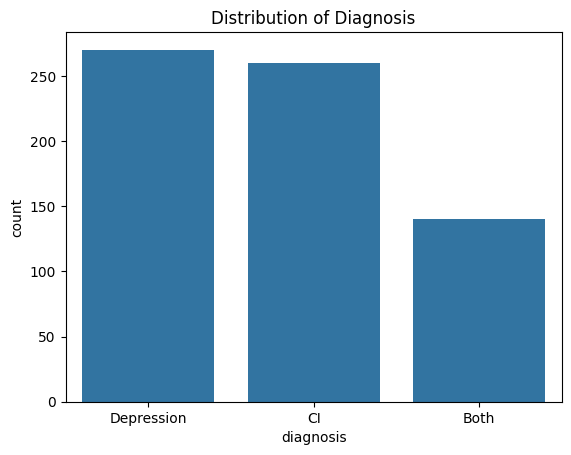

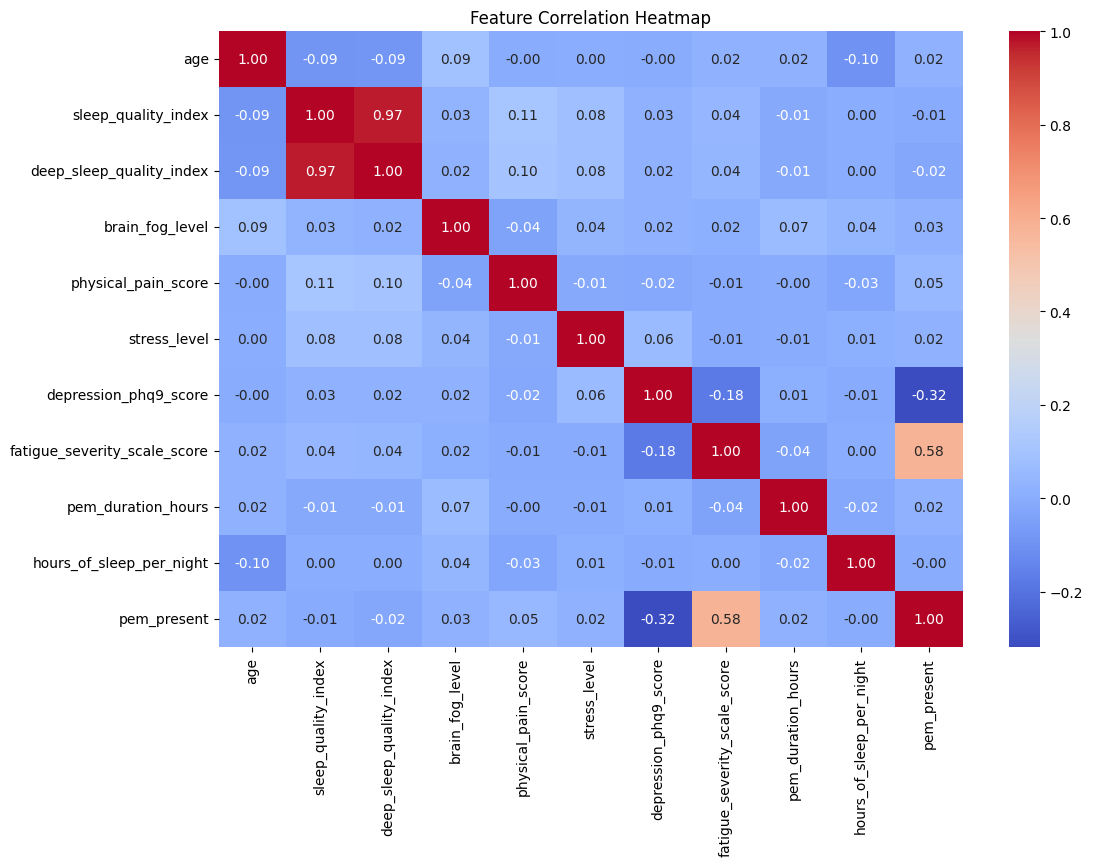

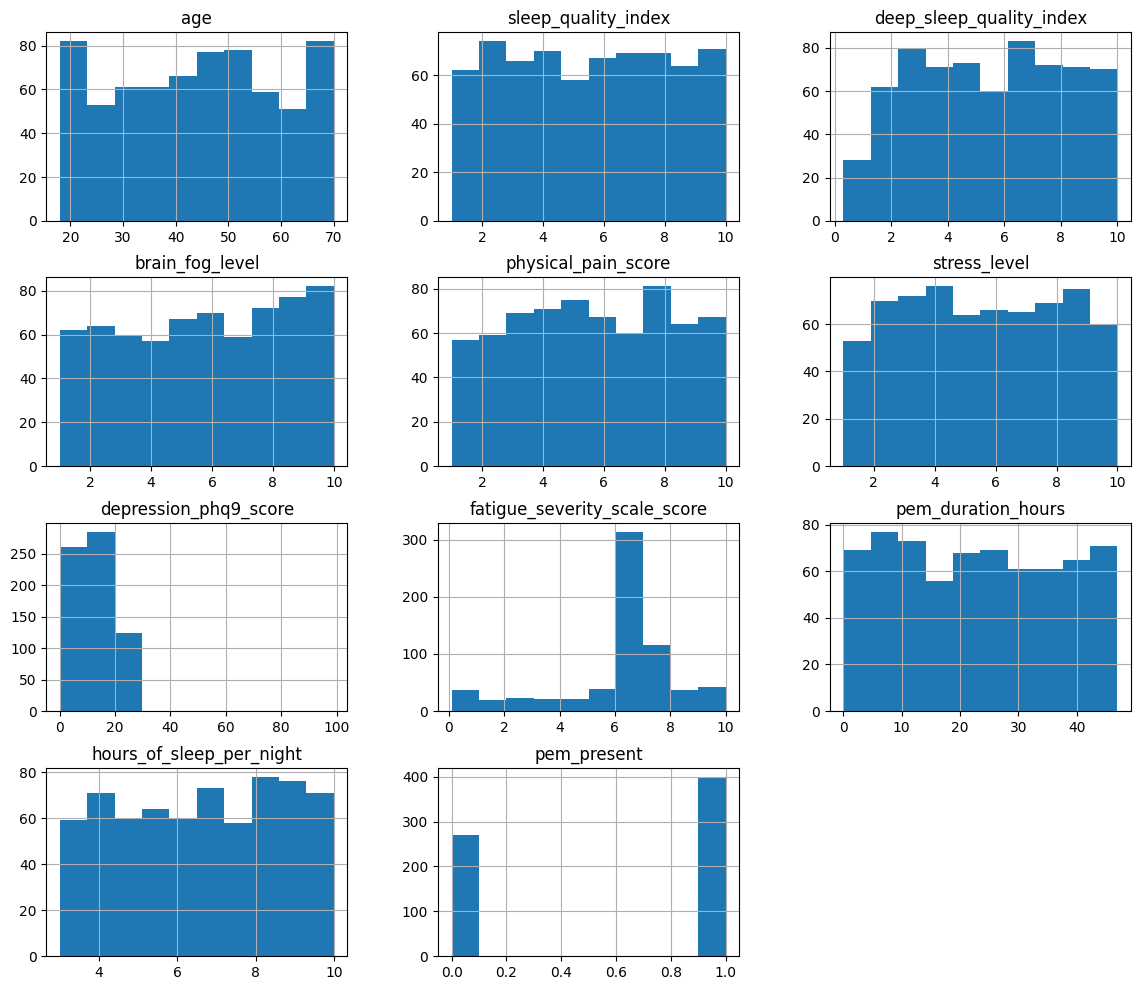

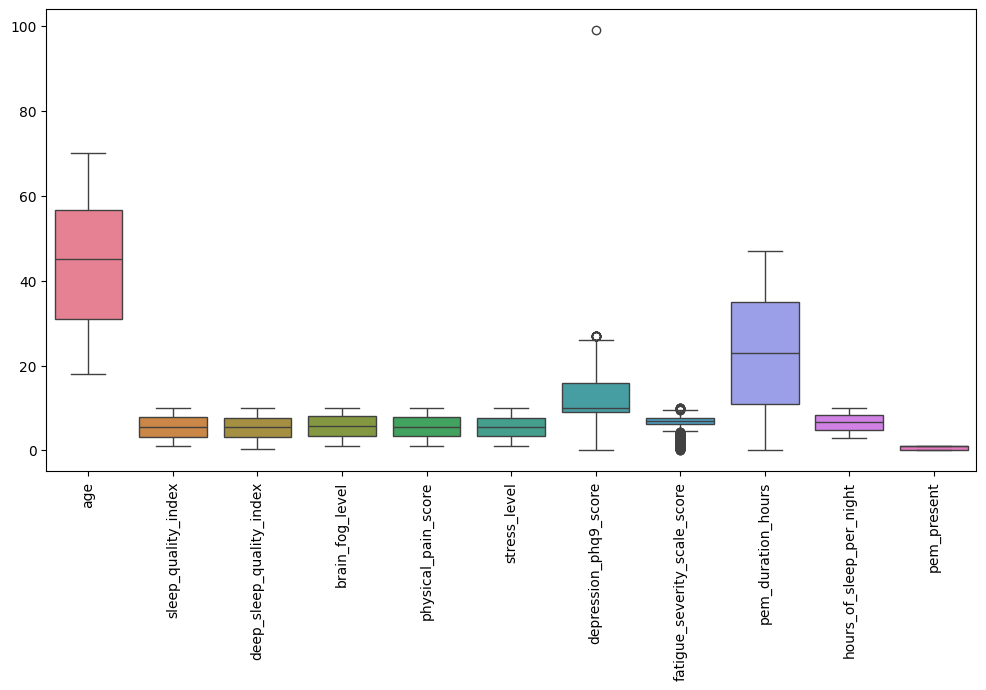

In [12]:
df = pd.read_csv('dataset_prepared.csv')
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['country'].value_counts())
df = df.drop(columns=["id", "country"])
df.head()


# 1. Diagnosis
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Diagnosis')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Histogram
df.hist(figsize=(14,12))
plt.show()

# 4. Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

df = df[df['depression_phq9_score'] <= 27]
df = df.drop(columns=["deep_sleep_quality_index"])

In [13]:
# Mapping
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

social_map = {'Very low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very high': 4}
exercise_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Daily': 4}
work_map = {'Not working': 0, 'Partially working': 1, 'Working': 2}

df['social_activity_level'] = df['social_activity_level'].map(social_map)
df['exercise_frequency'] = df['exercise_frequency'].map(exercise_map)
df['work_status'] = df['work_status'].map(work_map)

# Label Encoding
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['meditation_or_mindfulness'] = le.fit_transform(df['meditation_or_mindfulness'])

le_diagnosis = LabelEncoder()
df['diagnosis'] = le_diagnosis.fit_transform(df['diagnosis'])

In [14]:
# Drop columns
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# 2. Split training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

cv_protocol = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training Data: {len(X_train)} ")
print(f"Tesing Data: {len(X_test)} ")

Training Data: 535 
Tesing Data: 134 


In [15]:
# Create Models
logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

svm_model = make_pipeline(
    StandardScaler(),
    svm.SVC()
)
rf_model = make_pipeline(
    RandomForestClassifier(random_state=42)
)

---

# 2. **Model Training**

Here, you need to:

1.	select and compare at least three machine learning models (seen/discussed during the lectures) appropriate for your modelling;
2.	if there are hyperparameters in a selected algorithm, define a hyperparameter search protocol (you can define your own), and tune them.


In [16]:
# 1. Logistic Regression
logreg_param_grid = {
    'logisticregression__C': [0.1, 1, 10, 100]
}

# 2. SVM
svm_param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto']
    }
]

# 3. Random Forest
rf_param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [None, 10, 20]
}

model_search_configs = [
    ('Logistic Regression', logreg_model, logreg_param_grid),
    ('SVM', svm_model, svm_param_grid),
    ('Random Forest', rf_model, rf_param_grid)
]

search_results = []
best_estimators = {}
all_cv_results = []

for name, model, params in model_search_configs:
    print(f"Running GridSearchCV for {name}...")
    grid = GridSearchCV(
        model,
        params,
        cv=cv_protocol,
        scoring='balanced_accuracy',
        return_train_score=True,
        n_jobs=-1
        )
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    search_results.append({
        'Model': name,
        'Best_Params': grid.best_params_,
        'Best_CV_Score': grid.best_score_
    })

    cv_df = pd.DataFrame(grid.cv_results_)
    cv_df['Model'] = name
    all_cv_results.append(cv_df)

all_results_df = pd.concat(all_cv_results, ignore_index=True)

# Results
all_results_df = all_results_df[
    ['Model', 'params', 'mean_test_score', 'std_test_score', 'mean_train_score']
].rename(columns={
    'mean_test_score': 'mean_cv_balanced_accuracy',
    'std_test_score': 'std_cv_balanced_accuracy',
    'mean_train_score': 'mean_train_balanced_accuracy'
})

print(all_results_df)

each_results_df = pd.DataFrame(search_results).sort_values('Best_CV_Score', ascending=False)

print("\n=== Best result per model (CV balanced accuracy) ===")
print(each_results_df)

Running GridSearchCV for Logistic Regression...
Running GridSearchCV for SVM...
Running GridSearchCV for Random Forest...
                  Model                                             params  \
0   Logistic Regression                     {'logisticregression__C': 0.1}   
1   Logistic Regression                       {'logisticregression__C': 1}   
2   Logistic Regression                      {'logisticregression__C': 10}   
3   Logistic Regression                     {'logisticregression__C': 100}   
4                   SVM           {'svc__C': 0.1, 'svc__kernel': 'linear'}   
5                   SVM             {'svc__C': 1, 'svc__kernel': 'linear'}   
6                   SVM            {'svc__C': 10, 'svc__kernel': 'linear'}   
7                   SVM  {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__k...   
8                   SVM  {'svc__C': 0.1, 'svc__gamma': 'auto', 'svc__ke...   
9                   SVM  {'svc__C': 1, 'svc__gamma': 'scale', 'svc__ker...   
10                  

In [ ]:
# Changing the tree depth to small number
dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("DecisionTree (depth=2) test balanced accuracy:", balanced_accuracy_score(y_test, y_pred))

from sklearn import tree
print(tree.export_text(dt, feature_names=list(X_train.columns)))

DecisionTree (depth=2) test balanced accuracy: 1.0
|--- pem_present <= 0.50
|   |--- class: 2
|--- pem_present >  0.50
|   |--- depression_phq9_score <= 9.50
|   |   |--- class: 1
|   |--- depression_phq9_score >  9.50
|   |   |--- class: 0



---

# 3. **Evaluate models**

Here, you need to:

1.	test the model (the best one you obtained from the above stage) on the appropriate set.


Best model selected: Logistic Regression

=== Test Set Performance ===
Balanced Accuracy: 1.00
Accuracy: 1.00
Macro F1-score: 1.00
Macro Precision: 1.00
Macro Recall: 1.00
Macro ROC-AUC: 1.0


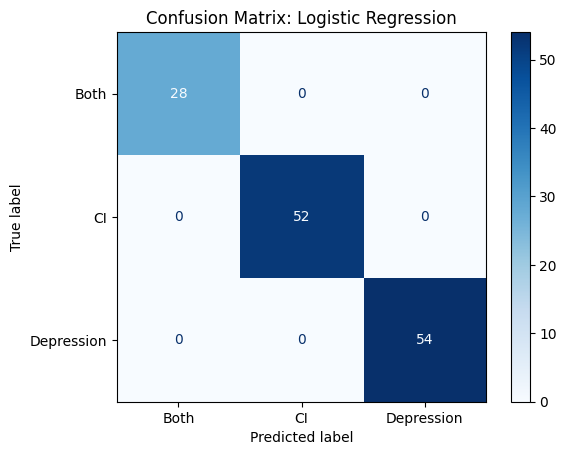


=== Classification Report ===
              precision    recall  f1-score   support

        Both       1.00      1.00      1.00        28
          CI       1.00      1.00      1.00        52
  Depression       1.00      1.00      1.00        54

    accuracy                           1.00       134
   macro avg       1.00      1.00      1.00       134
weighted avg       1.00      1.00      1.00       134



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

best_model_name = each_results_df.iloc[0]['Model']
best_model = best_estimators[best_model_name]

print("Best model selected:", best_model_name)

y_pred = best_model.predict(X_test)

bal_acc = balanced_accuracy_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

y_prob = best_model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=[0,1,2])

roc_auc = roc_auc_score(y_test_bin, y_prob, average='macro')


print("\n=== Test Set Performance ===")
print(f"Balanced Accuracy: {bal_acc:.2f}")
print(f"Accuracy: {acc:.2f}")
print(f"Macro F1-score: {f1:.2f}")
print(f"Macro Precision: {precision:.2f}")
print(f"Macro Recall: {recall:.2f}")
print(f"Macro ROC-AUC: {roc_auc}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# le_diagnosis.classes_ CI, Depression, Both
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_diagnosis.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()

# 4. Final Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_diagnosis.classes_))